# GoogLeNet - KHOTAA Diabetic Foot Ulcer Classification

## 1. Imports & Configuration

In [1]:
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import googlenet, GoogLeNet_Weights
import numpy as np
from sklearn.model_selection import StratifiedKFold
import importlib

sys.path.append('../')
sys.path.append('./')

from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing
from utils import checkpoint_manager, training_engine
importlib.reload(checkpoint_manager)  # Reload to remove N/A print
importlib.reload(training_engine)  # Reload to get latest fixes
from utils.checkpoint_manager import CheckpointManager
from utils.training_engine import TrainingEngine, create_optimizer
from utils.metrics_evaluator import (
    calculate_metrics, print_metrics, plot_confusion_matrix,
    plot_roc_curve, plot_training_history
)

print("✓ Imports complete (modules reloaded)")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Imports complete (modules reloaded)
PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Load Dataset

In [2]:
# Load dataset
loader = SplitFolderDatasetLoader(root_dir='../../dfu-dataset-annotated-into-4-classes')
classes = loader.get_classes()
num_classes = loader.get_num_classes()

print(f"Classes: {classes}")
print(f"Number of classes: {num_classes}")

# Initialize preprocessing
preprocessor = DFUPreprocessing()
train_transform = preprocessor.get_train_transforms()
val_test_transform = preprocessor.get_valid_test_transforms()

# Dataset class
class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        from PIL import Image
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Prepare data for cross-validation
X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])  # Concatenate numpy arrays
y_all = np.concatenate([y_train, y_val])

# Test set (untouched until final evaluation)
X_test, y_test = loader.load_split_paths('test')
test_dataset = DFUDataset(X_test, y_test, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)  # num_workers=0 to avoid multiprocessing issues

# Initialize 5-fold stratified cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nTotal training samples (train+valid): {len(X_all)}")
print(f"Test samples: {len(X_test)}")
print("✓ Dataset loaded and ready for 5-fold cross-validation")

[DatasetLoader] Root: c:\Users\reema\OneDrive\سطح المكتب\KHOTAA\KHOTAA\dfu-dataset-annotated-into-4-classes
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Classes: ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Number of classes: 4
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 9639 images
[DatasetLoader] Split 'valid': 282 images
[DatasetLoader] Split 'test': 141 images

Total training samples (train+valid): 9921
Test samples: 141
✓ Dataset loaded and ready for 5-fold cross-validation


## 3. Model Definition

In [3]:
# Setup device and loss function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

print(f"Device: {device}")

# Create GoogLeNet model
def create_googlenet_model(num_classes=4, pretrained=True):
    """
    Create GoogLeNet (Inception v1) model for DFU classification.
    
    Args:
        num_classes: Number of output classes (4 for DFU grades)
        pretrained: Use ImageNet pretrained weights
    
    Returns:
        GoogLeNet model configured for DFU classification
    """
    if pretrained:
        model = models.googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1)
    else:
        model = models.googlenet(weights=None)
    
    # Modify final classifier layer
    # GoogLeNet uses 'fc' for the main classifier
    # GoogLeNet classifier is: Linear(1024 -> 1000)
    # Replace with: Linear(1024 -> num_classes)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    # Also modify auxiliary classifiers for training stability (if they exist)
    if hasattr(model, 'AuxLogits') and hasattr(model.AuxLogits, 'fc'):
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
    
    return model

# Test model creation
test_model = create_googlenet_model(num_classes=num_classes)
print(f"\n✓ GoogLeNet (Inception v1) model created")
print(f"Input size: 224x224")
print(f"Output classes: {num_classes}")
print(f"Main classifier: {test_model.fc}")
if hasattr(test_model, 'AuxLogits'):
    print(f"Auxiliary classifier: {test_model.AuxLogits.fc}")

Device: cpu

✓ GoogLeNet (Inception v1) model created
Input size: 224x224
Output classes: 4
Main classifier: Linear(in_features=1024, out_features=4, bias=True)


## 4. Training

In [4]:
# 5-Fold Cross-Validation Training
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all, y_all), 1):
    print(f"\n{'='*60}\nFOLD {fold}/5\n{'='*60}")
    
    # Prepare fold data (X_all is numpy array of paths)
    X_train_fold = X_all[train_idx]
    y_train_fold = y_all[train_idx]
    X_val_fold = X_all[val_idx]
    y_val_fold = y_all[val_idx]
    
    train_dataset = DFUDataset(X_train_fold, y_train_fold, transform=train_transform)
    val_dataset = DFUDataset(X_val_fold, y_val_fold, transform=val_test_transform)
    
    # num_workers=0 to avoid multiprocessing issues with notebook-defined classes
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    # Create model
    model = create_googlenet_model(num_classes=num_classes, pretrained=True)
    model = model.to(device)
    
    # Setup optimizer using helper function (SGD with momentum=0.8)
    optimizer = create_optimizer(model, lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    checkpoint_manager = CheckpointManager(base_dir='checkpoints', experiment_name=f'googlenet_fold{fold}')
    engine = TrainingEngine(model=model, device=device)
    
    # Train
    history = engine.train(
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=30,
        scheduler=scheduler,
        checkpoint_manager=checkpoint_manager,
        early_stopping_patience=7,
        use_early_stopping=True,
        verbose=True
)
    
    # Store results
    best_val_acc = max(history['val_acc'])
    fold_results.append({
        'fold': fold,
        'best_val_acc': best_val_acc,
        'final_val_acc': history['val_acc'][-1],
        'stopped_epoch': history['stopped_epoch'],
        'history': history
    })
    print(f"Fold {fold} - Best Acc: {best_val_acc*100:.2f}% (stopped at epoch {history['stopped_epoch']})")

# Cross-validation summary
avg_acc = np.mean([r['best_val_acc'] for r in fold_results])
std_acc = np.std([r['best_val_acc'] for r in fold_results])
avg_epochs = np.mean([r['stopped_epoch'] for r in fold_results])

print(f"\n{'='*60}")
print(f"5-FOLD CROSS-VALIDATION RESULTS")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"\nIndividual Fold Results:")
for r in fold_results:
    print(f"  Fold {r['fold']}: {r['best_val_acc']*100:.2f}% (epoch {r['stopped_epoch']})")
print(f"{'='*60}")


FOLD 1/5
Created SGD optimizer: lr=0.001, momentum=0.8, weight_decay=0.0001
Training on: cpu

Epoch 1/30


Evaluating: 100%|██████████| 63/63 [01:46<00:00,  1.69s/it, loss=0.9418, acc=54.01%]


Learning Rate: 0.001000

Epoch 1 Results:
   Train Loss: 1.2582 | Train Acc: 43.06%
   Val Loss:   1.1088 | Val Acc:   54.01%
SUCCESS: Checkpoint saved: checkpoints\googlenet_fold1\fold_1\checkpoint_epoch_1.pth
SUCCESS: Best model saved: checkpoints\googlenet_fold1\fold_1\best_accuracy.pt
New best model! Val Acc: 54.01%

Epoch 2/30


Evaluating: 100%|██████████| 63/63 [01:41<00:00,  1.62s/it, loss=1.1731, acc=62.77%]


Learning Rate: 0.001000

Epoch 2 Results:
   Train Loss: 1.0229 | Train Acc: 56.59%
   Val Loss:   0.9238 | Val Acc:   62.77%
SUCCESS: Checkpoint saved: checkpoints\googlenet_fold1\fold_1\checkpoint_epoch_2.pth
SUCCESS: Best model saved: checkpoints\googlenet_fold1\fold_1\best_accuracy.pt
New best model! Val Acc: 62.77%

Epoch 3/30


...

Learning Rate: 0.000010

Epoch 28 Results:
   Train Loss: 0.4061 | Train Acc: 85.03%
   Val Loss:   0.3806 | Val Acc:   86.59%
SUCCESS: Checkpoint saved: checkpoints\googlenet_fold5\fold_1\checkpoint_epoch_28.pth

Epoch 29/30


Evaluating: 100%|██████████| 62/62 [01:44<00:00,  1.68s/it, loss=0.6593, acc=86.69%]


Learning Rate: 0.000010

Epoch 29 Results:
   Train Loss: 0.3963 | Train Acc: 85.90%
   Val Loss:   0.3829 | Val Acc:   86.69%
SUCCESS: Checkpoint saved: checkpoints\googlenet_fold5\fold_1\checkpoint_epoch_29.pth

Epoch 30/30


Evaluating: 100%|██████████| 62/62 [01:38<00:00,  1.59s/it, loss=0.5737, acc=86.24%]

Learning Rate: 0.000001

Epoch 30 Results:
   Train Loss: 0.3964 | Train Acc: 85.59%
   Val Loss:   0.3993 | Val Acc:   86.24%
SUCCESS: Checkpoint saved: checkpoints\googlenet_fold5\fold_1\checkpoint_epoch_30.pth

SUCCESS: Training Complete!
Completed all 30 epochs
Best Validation Accuracy: 87.95%

Fold 5 - Best Acc: 87.95% (stopped at epoch 30)

5-FOLD CROSS-VALIDATION RESULTS
Mean Accuracy: 88.34% ± 1.07%
Average Epochs: 29.4

Individual Fold Results:
  Fold 1: 89.37% (epoch 30)
  Fold 2: 89.62% (epoch 30)
  Fold 3: 88.10% (epoch 28)
  Fold 4: 86.64% (epoch 29)
  Fold 5: 87.95% (epoch 30)


## 5. Save Cross-Validation Results

✓ Results directory created: results\googlenet
✓ Directory verified: c:\Users\reema\OneDrive\سطح المكتب\KHOTAA\KHOTAA\models\classification\results\googlenet


c:\Users\reema\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


✓ Loaded best model from checkpoints/googlenet_fold2/fold_1/best_accuracy.pt


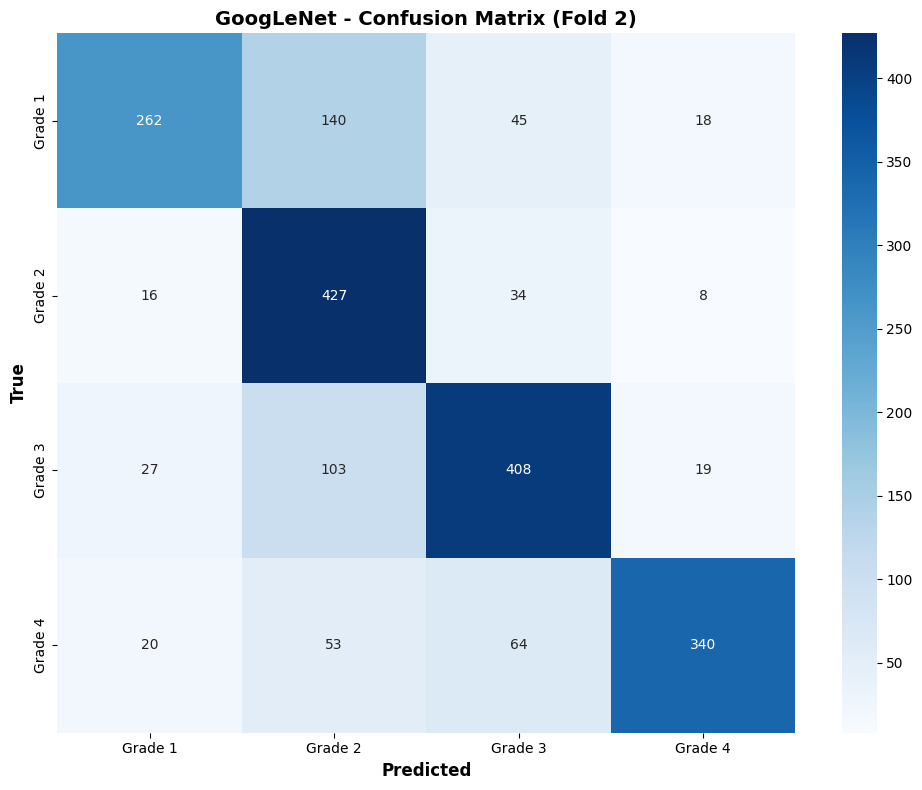

Generating aggregated confusion matrix across all folds...


c:\Users\reema\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


✓ Fold 1 processed


c:\Users\reema\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


✓ Fold 2 processed


...

✓ Fold 3 processed


c:\Users\reema\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


✓ Fold 4 processed


c:\Users\reema\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


✓ Fold 5 processed


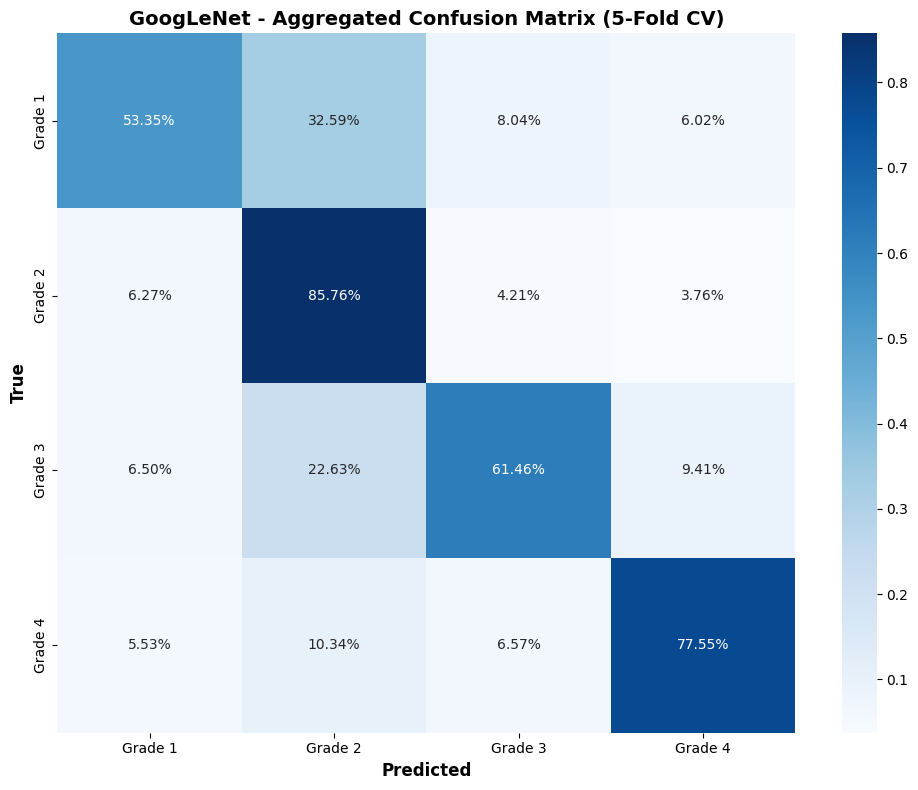

✓ Aggregated confusion matrix saved (9921 total predictions)


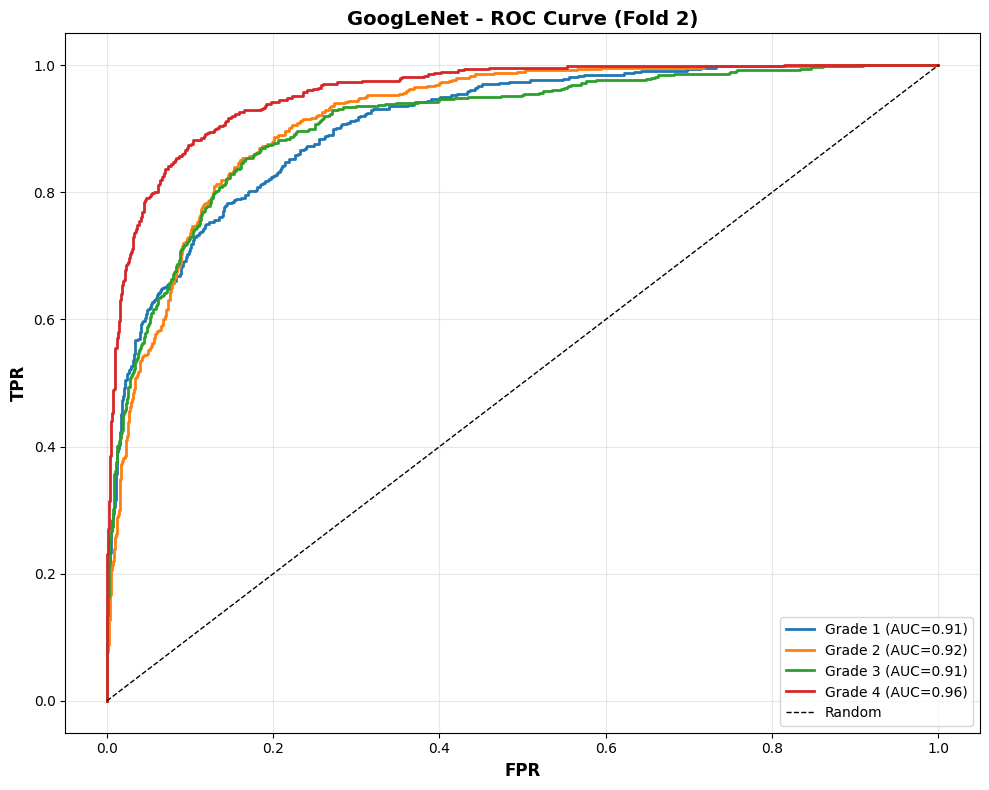

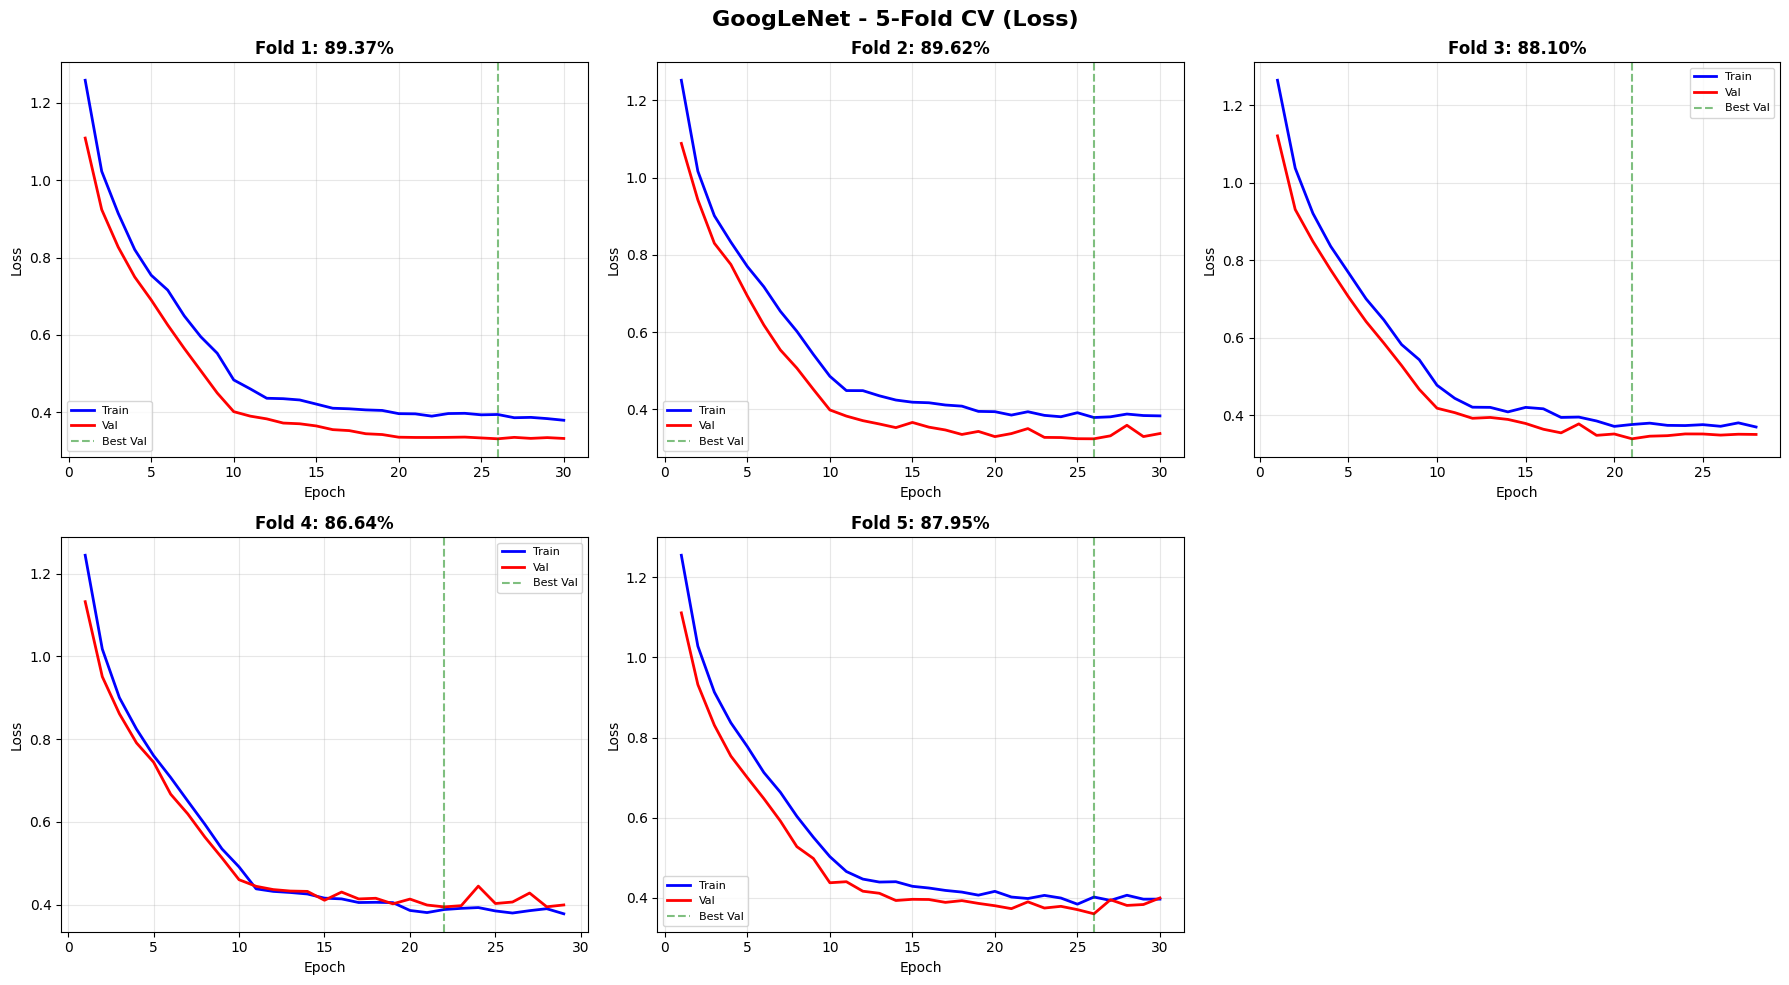

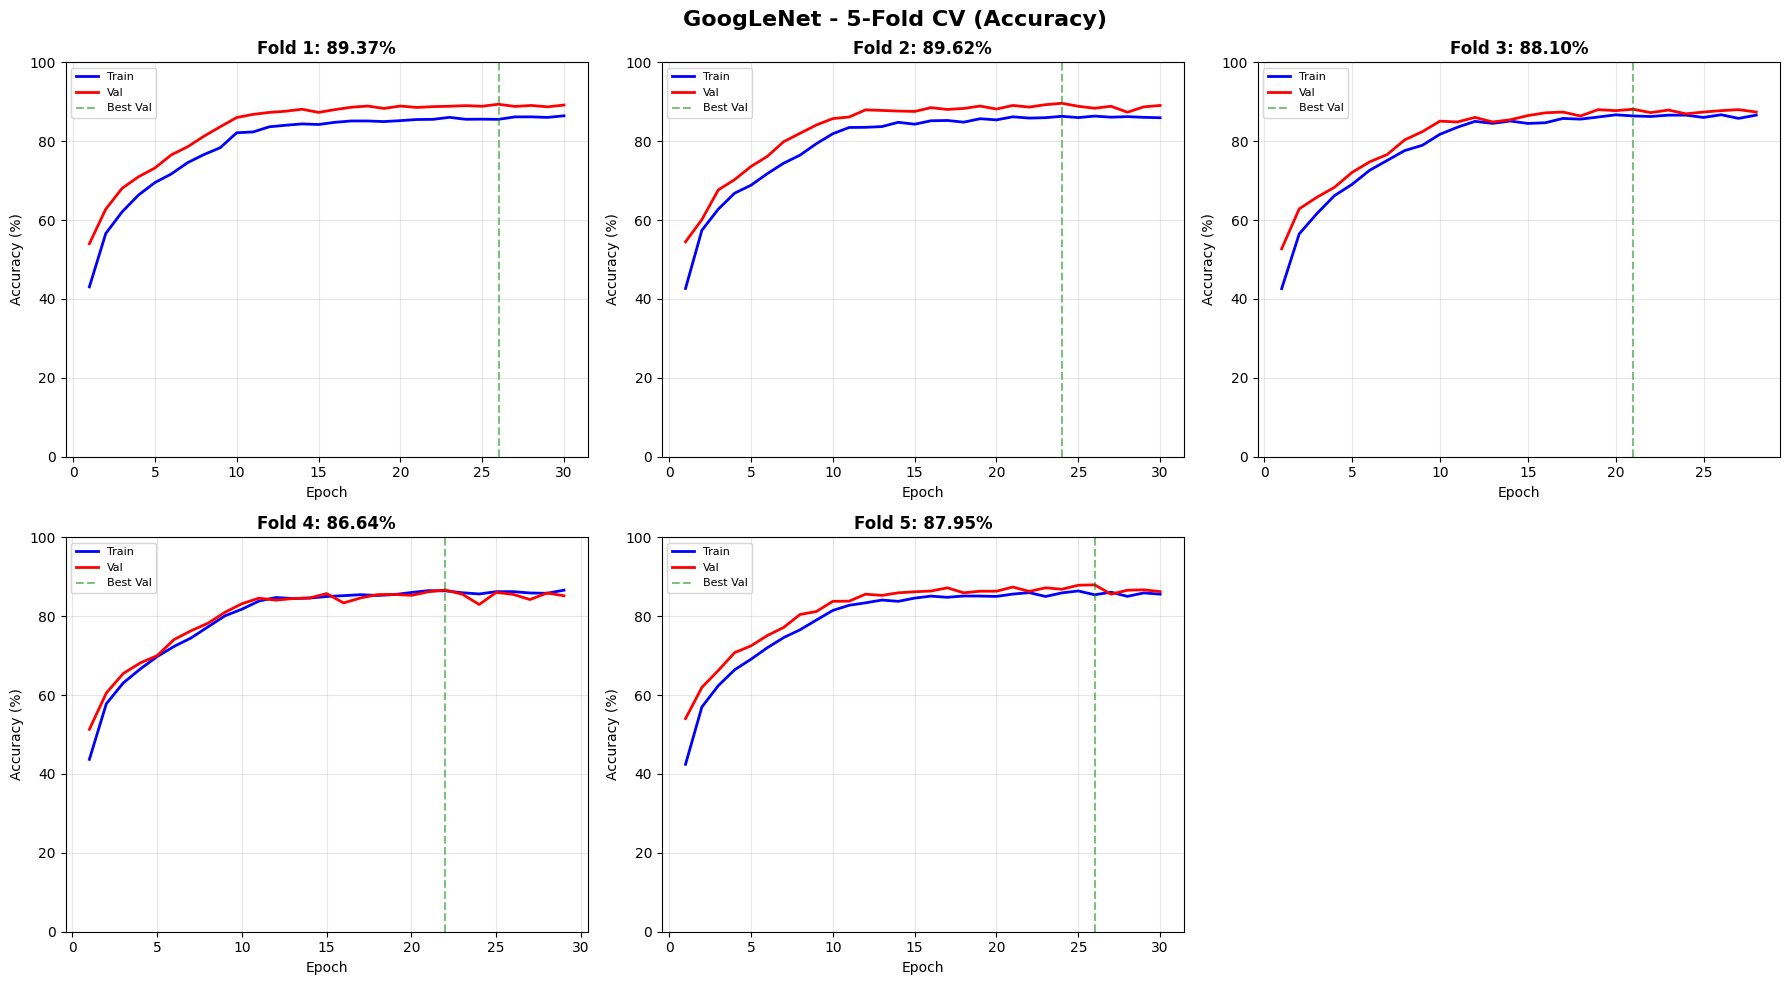


GoogLeNet CROSS-VALIDATION SUMMARY
Mean Accuracy: 88.34% ± 1.07%
Best Fold: 2 (89.62%)
Average Epochs: 29.4


In [12]:
# 5. Save Cross-Validation Results
MODEL_NAME = 'GoogLeNet'
BATCH_SIZE = 32
RESULTS_DIR = 'results'
CHECKPOINT_DIR = 'checkpoints'
N_FOLDS = 5
DPI = 300

# Plotting configuration
PLOT_CONFIG = {
    'cm': {'size': (10, 8), 'cmap': 'Blues'},
    'roc': {'size': (10, 8), 'lw': 2},
    'history': {'size': (18, 10)},
    'comparison': {'size': (10, 6)}
}
FONT = {'title': 14, 'label': 12, 'legend': 10, 'tick': 10}

# Save Cross-Validation Results and Generate Plots
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

# Create model-specific results directory
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
os.makedirs(model_results_dir, exist_ok=True)
print(f"✓ Results directory created: {model_results_dir}")

# Verify directory exists
if os.path.exists(model_results_dir):
    print(f"✓ Directory verified: {os.path.abspath(model_results_dir)}")
else:
    print(f"⚠ Warning: Directory not found, creating again...")
    os.makedirs(model_results_dir, exist_ok=True)

# Get best fold
best_fold_idx = np.argmax([r['best_val_acc'] for r in fold_results])
best_fold_num = fold_results[best_fold_idx]['fold']

# Recreate validation set for best fold
fold_splits = list(kfold.split(X_all, y_all))
train_idx, val_idx = fold_splits[best_fold_idx]
val_dataset = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Load best model
checkpoint_path = f'{CHECKPOINT_DIR}/googlenet_fold{best_fold_num}/fold_1/best_accuracy.pt'

# Check if checkpoint exists
if not os.path.exists(checkpoint_path):
    print(f"Warning: Checkpoint not found at {checkpoint_path}")
else:
    def create_googlenet_model_for_eval(num_classes=4):
        model = models.googlenet(weights=None, aux_logits=False)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model
    model = create_googlenet_model_for_eval(num_classes=num_classes)
    model.load_state_dict(torch.load(checkpoint_path))
    model = model.to(device).eval()
    print(f"✓ Loaded best model from {checkpoint_path}")

# Get predictions
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions = np.concatenate(all_preds)
true_labels = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

# 1. Confusion Matrix (Raw Counts)
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm, annot=True, fmt='d', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - Confusion Matrix (Fold {best_fold_num})', 
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix.png', dpi=DPI, bbox_inches='tight')
plt.show()

# 2. Aggregated Confusion Matrix (All 5 Folds)
print("Generating aggregated confusion matrix across all folds...")
cm_aggregated = np.zeros((num_classes, num_classes), dtype=int)

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, 1):
    # Recreate validation set for this fold
    val_dataset_fold = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
    val_loader_fold = DataLoader(val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Load model for this fold
    fold_checkpoint_path = f'{CHECKPOINT_DIR}/googlenet_fold{fold_idx}/fold_1/best_accuracy.pt'
    if os.path.exists(fold_checkpoint_path):
        model_fold = create_googlenet_model_for_eval(num_classes=num_classes)
        model_fold.load_state_dict(torch.load(fold_checkpoint_path))
        model_fold = model_fold.to(device).eval()
        
        # Get predictions for this fold
        fold_preds, fold_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader_fold:
                outputs = model_fold(inputs.to(device))
                fold_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
                fold_labels.append(labels.numpy())
        
        # Accumulate confusion matrix
        fold_predictions = np.concatenate(fold_preds)
        fold_true_labels = np.concatenate(fold_labels)
        cm_fold = confusion_matrix(fold_true_labels, fold_predictions, labels=range(num_classes))
        cm_aggregated += cm_fold
        print(f"✓ Fold {fold_idx} processed")
    else:
        pass

# Normalize aggregated confusion matrix
cm_aggregated_norm = cm_aggregated.astype('float') / cm_aggregated.sum(axis=1)[:, np.newaxis]

# Plot aggregated confusion matrix
fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm_aggregated_norm, annot=True, fmt='.2%', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - Aggregated Confusion Matrix (5-Fold CV)', 
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix_aggregated.png', dpi=DPI, bbox_inches='tight')
plt.show()

print(f"✓ Aggregated confusion matrix saved ({cm_aggregated.sum()} total predictions)")

# 3. ROC Curve
y_true_bin = label_binarize(true_labels, classes=range(num_classes))
fig, ax = plt.subplots(figsize=PLOT_CONFIG['roc']['size'])

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, linewidth=PLOT_CONFIG['roc']['lw'], 
            label=f'{classes[i]} (AUC={auc(fpr, tpr):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('TPR', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - ROC Curve (Fold {best_fold_num})', 
             fontsize=FONT['title'], fontweight='bold')
ax.legend(loc='lower right', fontsize=FONT['legend'])
ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_roc_curve.png', dpi=DPI, bbox_inches='tight')
plt.show()

# 4. All Folds Training History (Loss)
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} - {N_FOLDS}-Fold CV (Loss)', fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    history = r['history']
    epochs = range(1, len(history['train_loss']) + 1)
    
    ax.plot(epochs, history['train_loss'], 'b-', label='Train', lw=2)
    ax.plot(epochs, history['val_loss'], 'r-', label='Val', lw=2)
    ax.axvline(x=history['val_loss'].index(min(history['val_loss'])) + 1, 
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(epochs):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Loss', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_loss.png', dpi=DPI, bbox_inches='tight')
plt.show()

# 5. All Folds Training History (Accuracy)
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} - {N_FOLDS}-Fold CV (Accuracy)', fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    history = r['history']
    epochs = range(1, len(history['train_acc']) + 1)
    
    # Convert to percentage
    train_acc_pct = [acc * 100 for acc in history['train_acc']]
    val_acc_pct = [acc * 100 for acc in history['val_acc']]
    
    ax.plot(epochs, train_acc_pct, 'b-', label='Train', lw=2)
    ax.plot(epochs, val_acc_pct, 'r-', label='Val', lw=2)
    ax.axvline(x=history['val_acc'].index(max(history['val_acc'])) + 1, 
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(epochs):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Accuracy (%)', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 100])

axes[1, 2].axis('off')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_accuracy.png', dpi=DPI, bbox_inches='tight')
plt.show()

# Save results
results = {
    'model_name': MODEL_NAME,
    'cv_results': {
        'val_accuracy': {'mean': float(avg_acc), 'std': float(std_acc)},
        'avg_epochs': float(avg_epochs),
        'fold_results': [{'fold': r['fold'], 'best_val_acc': float(r['best_val_acc']), 
                          'stopped_epoch': int(r['stopped_epoch'])} for r in fold_results]
    },
    'best_fold': {
        'fold_number': best_fold_num, 
        'best_val_acc': float(fold_results[best_fold_idx]['best_val_acc']),
        'checkpoint_path': checkpoint_path
    }
}

os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
with open(f'{model_results_dir}/{MODEL_NAME.lower()}_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*60}")
print(f"{MODEL_NAME} CROSS-VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Best Fold: {best_fold_num} ({fold_results[best_fold_idx]['best_val_acc']*100:.2f}%)")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"{'='*60}")